Saving Housing.csv to Housing (2).csv
--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None

Explained Variance Ratio: [0.4019416  0.21251931]


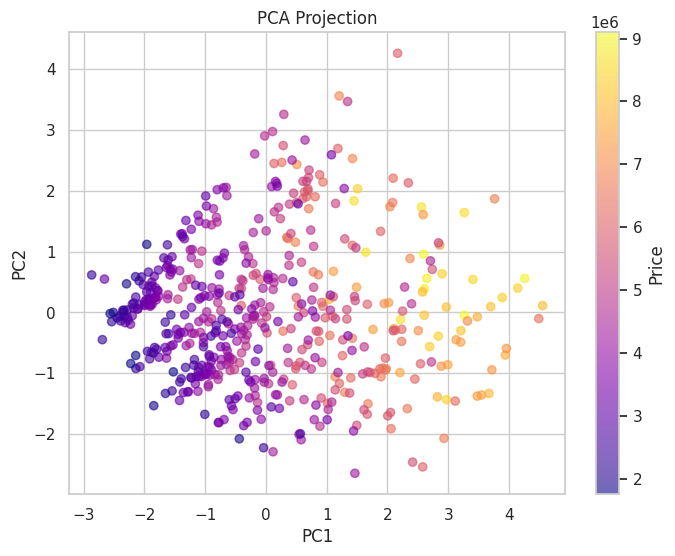

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from google.colab import files
import io

sns.set(style="whitegrid")

# تفعيل خاصية رفع الملف
uploaded = files.upload()

# الحصول على اسم الملف المرفوع تلقائياً لتجنب KeyError
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

# 1. استكشاف البيانات
print("--- Data Info ---")
print(df.info())

# 2. معالجة القيم المفقودة (Task 2)
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# 3. معالجة القيم الشاذة باستخدام IQR لعمود السعر (Task 3)
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_cleaned = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)].copy()

# 4. التقييس (Task 4)
scaler_mm = MinMaxScaler()
df_cleaned['price_MinMax'] = scaler_mm.fit_transform(df_cleaned[['price']])

scaler_ss = StandardScaler()
df_cleaned['price_Zscore'] = scaler_ss.fit_transform(df_cleaned[['price']])

# 5. تحليل المكونات الرئيسية PCA (Task 5)
pca_features = df_cleaned[numeric_cols]
scaled_pca_features = StandardScaler().fit_transform(pca_features)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_pca_features)

print("\nExplained Variance Ratio:", pca.explained_variance_ratio_)

# رسم النتائج
plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=df_cleaned['price'], cmap='plasma', alpha=0.6)
plt.colorbar(label='Price')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection')
plt.show()